# Model Evaluation

## Imports, data loading, and subsetting data based on `preprocessing.ipynb`

In [ ]:
import os # For preventing model retraining
from scipy import stats # For hypothesis testing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import lines # for random classifier line

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, validation_curve, learning_curve, cross_val_score, TunedThresholdClassifierCV

from IPython.display import Image

RANDOM_STATE = 42

In [ ]:
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

# To make below code not throw warnings about y_train's shape
y_train = np.ndarray.flatten(y_train.values)
y_test = np.ndarray.flatten(y_test.values)
y_train.shape

(6400,)

### Subset of `X_train` and `X_test` with high mutual information
From `preprocessing.ipynb`, we remove the features `nominal__offline_listening_1` and `max_abs__ads_listened_per_week`.

In [ ]:
mi_cols_to_drop = ['nominal__offline_listening_1', 'max_abs__ads_listened_per_week']
X_train_mi = X_train.drop(columns=mi_cols_to_drop)
X_test_mi = X_test.drop(columns=mi_cols_to_drop)

### Subset of `X_train` and `X_test` based on Recursive Feature Elimination with Cross Validation
From `preprocessing.ipynb`, we drop `nominal__country_IN`

(This was trained on a DTreeClassifier)

In [ ]:
rfecv_cols_to_drop = ['nominal__country_IN']
X_train_rfecv = X_train.drop(columns=rfecv_cols_to_drop)
X_test_rfecv = X_test.drop(columns=rfecv_cols_to_drop)

### Subset of `X_train` and `X_test` based on Sequential Feature Selection
From `preprocessing.ipynb`, we drop `nominal__device_type_Mobile`, `ordinal__subscription_type`, `nominal__device_type_Web`.

(This was trained on KNN)

In [ ]:
sfs_cols_to_drop = ['nominal__device_type_Mobile', 'ordinal__subscription_type',
                    'nominal__device_type_Web']
X_train_sfs = X_train.drop(columns=sfs_cols_to_drop)
X_test_sfs = X_test.drop(columns=sfs_cols_to_drop)

## Comparision of models over ROC-AUC
We use ROC-AUC because it is suitable for imbalanced data, and false negatives and false positives are not more important than one another. In Comparision to a model's $F_1$ Score, ROC-AUC does not change with classification threshold.

In [ ]:
"""Generate a dictionary of models with the
following key-value pairs:

Key:    tuple[str, str] -> name of model, name of subset of X_train to use
Value:  [SKLearn Constructor, str, pd.DataFrame, pd.DataFrame] ->
        (Appropiate model instance,
        subset of X_train to use,
        subset of X_test to use)

PLEASE NOTE: As SFS was trained on DTree and NOT KNN, we only use it for DTree.
Similarly, as RFECV was trained on KNN and NOT DTree, we only use it for KNN.
"""

# Sequential Feature Selection was put above to help with formatting in sns plot
models = {
          ('Decision Tree', 'Full'):                                (DecisionTreeClassifier(random_state=RANDOM_STATE),  X_train,      X_test),
          ('Decision Tree', 'Mutual Information'):                  (DecisionTreeClassifier(random_state=RANDOM_STATE),  X_train_mi,   X_test_mi),
          ('Decision Tree', 'Recursive Feature Elimination'):        (DecisionTreeClassifier(random_state=RANDOM_STATE), X_train_rfecv,  X_test_rfecv),
          ('K Nearest Neighbors', 'Full'):                          (KNeighborsClassifier(),                             X_train,      X_test),
          ('K Nearest Neighbors', 'Mutual Information'):            (KNeighborsClassifier(),                             X_train_mi,   X_test_mi),
          ('K Nearest Neighbors', 'Sequential Feature Selection'): (KNeighborsClassifier(),                              X_train_sfs,X_test_sfs),
          ('Logistic Regression', 'Full'):                          (LogisticRegression(),                               X_train,      X_test),
          ('Logistic Regression', 'Mutual Information'):            (LogisticRegression(),                               X_train_mi,   X_test_mi)
          }

### Comparision of models without cross validation

In [ ]:
roc_data = []

for model_subset_name, model_info in models.items():
  model_name, subset_name = model_subset_name
  model, X_train_subset, X_test_subset = model_info

  model.fit(X_train_subset, y_train)
  y_pred = model.predict(X_test_subset)

  fpr, tpr, thresholds = roc_curve(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred)

  df = pd.DataFrame({'fpr': fpr,
                     'tpr': tpr,
                     'thresholds': thresholds,
                     'model': model_name,
                     'subset': subset_name,
                     'auc': np.round(auc, 4),
                     'plot_info': f'{subset_name}: AUC = {np.round(auc, 4)}'
                     })
  roc_data.append(df)

roc_df = pd.concat(roc_data)
roc_df.head()


,fpr,tpr,thresholds,model,subset,auc,plot_info
0,0.000000,0.000,inf,Decision Tree,Full,0.5137,Full: AUC = 0.5137
1,0.267500,0.295,1.0,Decision Tree,Full,0.5137,Full: AUC = 0.5137
2,1.000000,1.000,0.0,Decision Tree,Full,0.5137,Full: AUC = 0.5137
0,0.000000,0.000,inf,Decision Tree,Mutual Information,0.4983,Mutual Information: AUC = 0.4983
1,0.283333,0.280,1.0,Decision Tree,Mutual Information,0.4983,Mutual Information: AUC = 0.4983


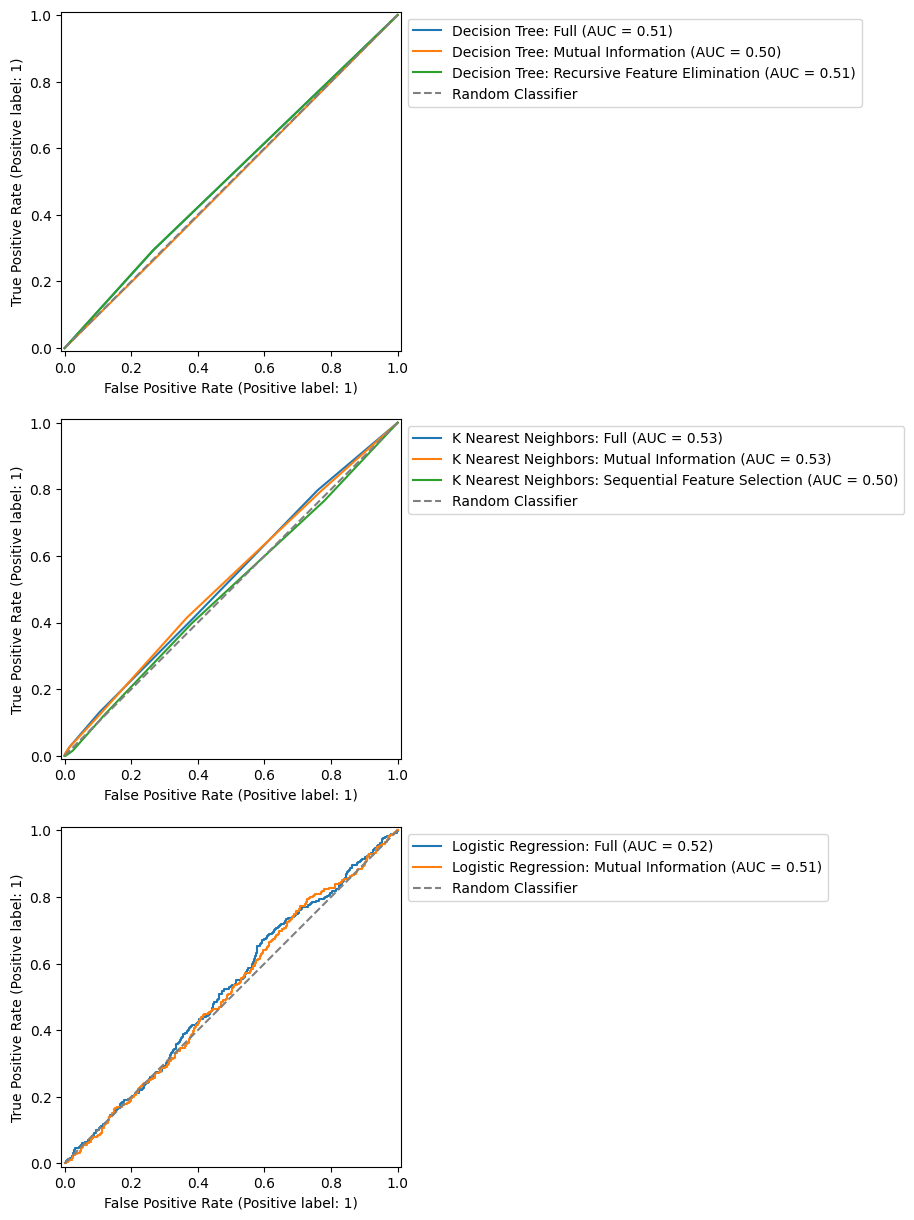

In [ ]:
model_to_ax = {'Decision Tree': 0, 'K Nearest Neighbors': 1, 'Logistic Regression': 2}

fig, axs = plt.subplots(3, 1, figsize=(5, 15))
axs = axs.flatten()

for i, (model_subset_name, model_info) in enumerate(models.items()):
  model_name, subset_name = model_subset_name
  model, X_train_subset, X_test_subset = model_info

  RocCurveDisplay.from_estimator(model,
                                 X_test_subset,
                                 y_test,
                                 name = f'{model_name}: {subset_name}',
                                 ax=axs[model_to_ax[model_name]])

  # Hacky way to make the random classifier only display once per axis
  if i in (2, 5, 7):
    axs[model_to_ax[model_name]].plot(
        [0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier'
        );
  axs[model_to_ax[model_name]].legend(loc='upper left', bbox_to_anchor=(1,1))

In [ ]:
mean_df = roc_df.groupby('model')['auc'].mean().rename('mean_auc')
std_df = roc_df.groupby('model')['auc'].std().rename('std_auc')
median_df = roc_df.groupby('model')['auc'].median().rename('median_auc')

pd.concat([mean_df, std_df, median_df], axis=1)

,mean_auc,std_auc,median_auc
model,,,
Decision Tree,0.508733,0.007828,0.5137
K Nearest Neighbors,0.507767,0.004900,0.5087
Logistic Regression,0.500000,0.000000,0.5000


### Findings of comparison
 - Models trained on the full subset of features perform the best
 - Decision Tree has a bump around 0.3 for False Positive and True Positive rates on it's threshold
 - K Nearest Neighbors performs best, although it's SFS performance is bad.
 - Logistic Regression performs better than a random classifier, although not as strongly as KNN

Models are dangerously close to performing as well as a random classifier



### Comparison with cross validation

In [ ]:
cv_results = []

for model_subset_name, model_info in models.items():
  model_name, subset_name = model_subset_name
  model, X_train_subset, X_test_subset = model_info

  scores = cross_val_score(model,
                           X_train_subset,
                           y_train,
                           cv=25,
                           scoring='roc_auc',
                           n_jobs=-1)

  for score in scores:
    cv_results.append({
        'model': model_name,
        'subset': subset_name,
        'score': score
    })

cv_df = pd.DataFrame(cv_results)
cv_df.head()

,model,subset,score
0,Decision Tree,Full,0.461324
1,Decision Tree,Full,0.453110
2,Decision Tree,Full,0.537081
3,Decision Tree,Full,0.486683
4,Decision Tree,Full,0.493169


/tmp/ipython-input-2312623809.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(['Full', 'Mutual Information', 'RFECV'])
/tmp/ipython-input-2312623809.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(['Full', 'Mutual Information', 'SFS'])
/tmp/ipython-input-2312623809.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Full', 'Mutual Information'])


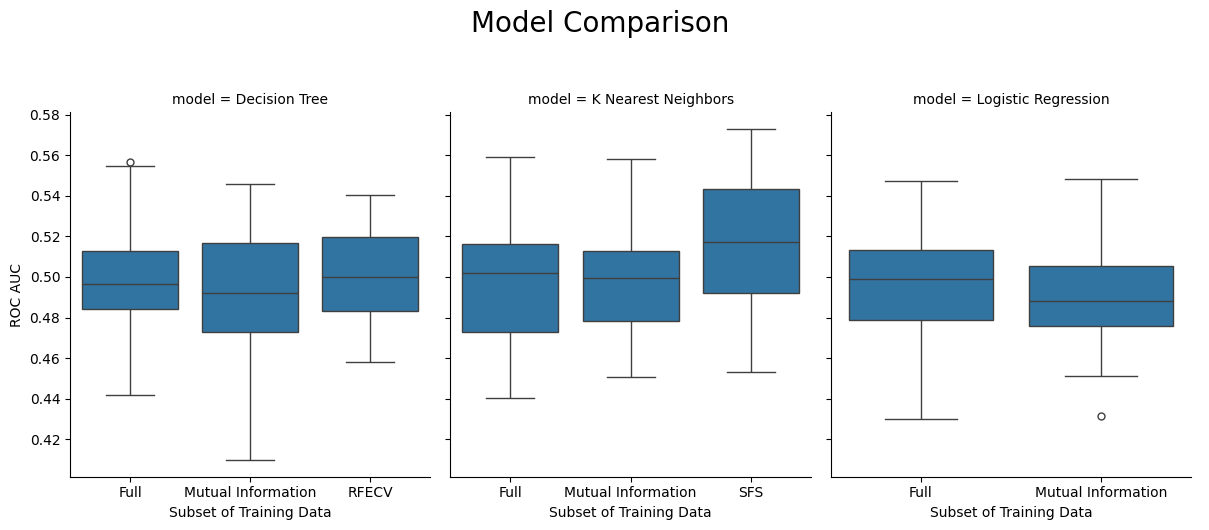

In [ ]:
g = sns.catplot(
    data=cv_df,
    x='subset',
    y='score',
    col='model',
    kind='box',
    col_wrap=3,
    sharex=False,
    height=5,
    aspect=0.8
)

g.fig.suptitle('Model Comparison', y=1.05, fontsize=20)
g.set_axis_labels("Subset of Training Data", "ROC AUC")
axs = g.axes.flatten()
axs[0].set_xticklabels(['Full', 'Mutual Information', 'RFECV'])
axs[1].set_xticklabels(['Full', 'Mutual Information', 'SFS'])
axs[2].set_xticklabels(['Full', 'Mutual Information'])
plt.tight_layout()
sns.despine()

In [ ]:
mean_scores = cv_df.groupby('model')['score'].mean().sort_values(ascending=False).rename('mean_auc')
std_scores = cv_df.groupby('model')['score'].std().rename('std_auc')
median_scores = cv_df.groupby('model')['score'].median().rename('median_auc')

pd.concat([mean_scores, std_scores, median_scores], axis=1)

,mean_auc,std_auc,median_auc
model,,,
K Nearest Neighbors,0.505058,0.030633,0.505765
Decision Tree,0.497753,0.027706,0.498460
Logistic Regression,0.492890,0.027203,0.492932


In [ ]:
mask = cv_df['model'] == 'K Nearest Neighbors'

mean_scores = cv_df[mask].groupby('subset')['score'].mean().rename('mean_auc')
std_scores = cv_df[mask].groupby('subset')['score'].std().rename('std_auc')
median_scores = cv_df[mask].groupby('subset')['score'].median().rename('median_auc')

pd.concat([mean_scores, std_scores, median_scores], axis=1)

,mean_auc,std_auc,median_auc
subset,,,
Full,0.500362,0.028661,0.501737
Mutual Information,0.497062,0.027894,0.499408
Sequential Feature Selection,0.517749,0.032195,0.517294


In [ ]:
full_sample = np.array(cv_df[mask & (cv_df['subset'] == 'Full')]['score'])
sfs_sample = np.array(cv_df[mask & (cv_df['subset'] == 'Sequential Feature Selection')]['score'])

t_statistic, p_value = stats.ttest_rel(full_sample, sfs_sample)
print(f't-statistic: {t_statistic}')
print(f'p-value: {p_value}')

t-statistic: -2.555409327970729
p-value: 0.01736411175071776


### Findings of Cross Validation Comparison
Based on the above, it makes sense to further investigate our K Nearest Neighbors models further.

As the standard deviation of `K Nearest Neighbors` on the `Full` subset is known ($0.028661$) as well as the mean for it's ROC-AUC ($0.500362$) and the standard deviation of `K Nearest Neighbors` on the  `Mutual Information` subset ($0.027894$) and it's mean for ROC-AUC ($0.497062$), we performed a two sample $t$-test on the data. As we found our $p$-value to be $0.017$, we reject the null hypothesis, meaning we can say with $98\%$ confidence our the `SFS` subset provides statistically significantly better results than the `Full` or `Mutual Information` subsets.

We will look at a grid search of K Nearest Neighbors on the `SFS` training subset, as it has highest potential for optimization due to the largest number of features.

## Grid Search on K Nearest Neighbors
In the spirit of the uploaded `model_evaluation.ipynb`, we will not perform an exhaustive grid search, instead we will compare results from change different parameters around

### $l_1$ versus $l_2$ space
As many of our columns are binary it may make sense to use an $l_1$ norm.

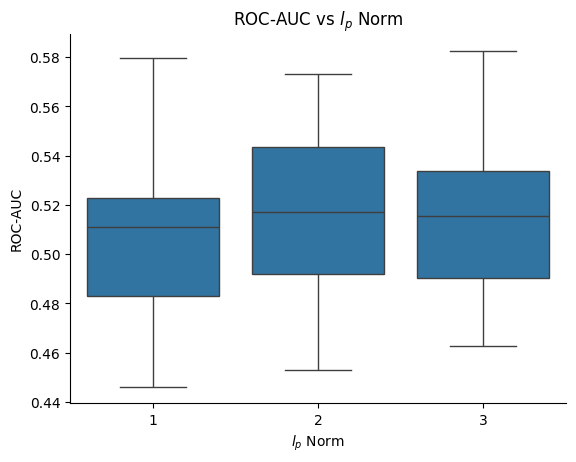

In [ ]:
cv_results = []

for i in range(1,4):
  scores = cross_val_score(KNeighborsClassifier(p=i),
                           X_train_sfs, y_train,
                           cv=25,
                           scoring='roc_auc',
                           n_jobs=-1)
  for score in scores:
    cv_results.append({
        'p': i,
        'ROC-AUC': score
    })

cv_df = pd.DataFrame(cv_results)
ax = sns.boxplot(data=cv_df,
                 x='p',
                 y='ROC-AUC');
ax.set_title('ROC-AUC vs $l_p$ Norm');
ax.set_xlabel('$l_p$ Norm');
sns.despine();

### Weighted vs Uniform distance
‘uniform’ : uniform weights. All points in each neighborhood are weighted equally.

‘distance’ : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.

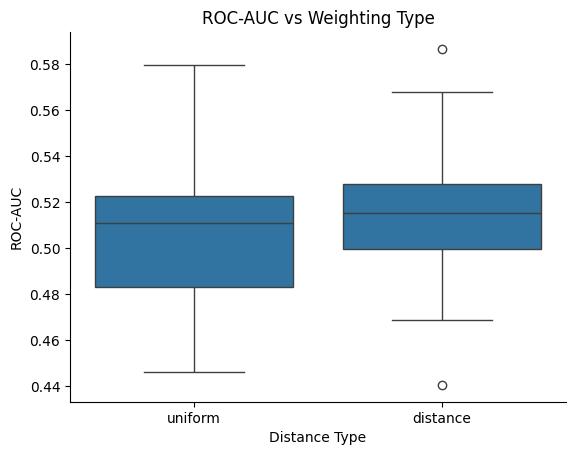

In [ ]:
cv_results = []
weights = ['uniform', 'distance']

for w in weights:
  scores = cross_val_score(KNeighborsClassifier(p=1, weights=w),
                           X_train_sfs, y_train,
                           cv=25,
                           scoring='roc_auc',
                           n_jobs=-1)
  for score in scores:
    cv_results.append({
        'weighting': w,
        'ROC-AUC': score
    })

cv_df = pd.DataFrame(cv_results)
ax = sns.boxplot(data=cv_df,
                 x='weighting',
                 y='ROC-AUC');
ax.set_title('ROC-AUC vs Weighting Type');
ax.set_xlabel('Distance Type');
sns.despine();

In [ ]:
uniform_sample = np.array(cv_df[(cv_df['weighting'] == 'uniform')]['ROC-AUC'])
distance_sample = np.array(cv_df[(cv_df['weighting'] == 'distance')]['ROC-AUC'])

t_statistic, p_value = stats.ttest_rel(uniform_sample, distance_sample)
print(f't-statistic: {t_statistic}')
print(f'p-value: {p_value}')

t-statistic: -2.175220509214861
p-value: 0.03969279366166292


### Comparison of number of neighbors to use

/tmp/ipython-input-61024259.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(num_neighbors);


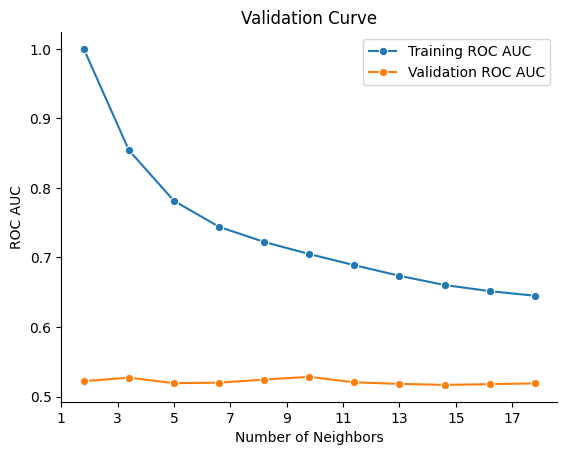

In [ ]:
num_neighbors = np.arange(1, 22, 2)

train_scores, val_scores = validation_curve(
    KNeighborsClassifier(p=1, n_jobs=-1),
    X_train_sfs, y_train,
    param_name="n_neighbors",
    param_range=num_neighbors,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)


ax = sns.lineplot(x=num_neighbors, y=train_mean, label="Training ROC AUC", marker="o")
sns.lineplot(x=num_neighbors, y=val_mean, label="Validation ROC AUC", marker="o")
ax.set_xlabel("Number of Neighbors")
ax.set_ylabel("ROC AUC");
ax.set_xticklabels(num_neighbors);
ax.set_title("Validation Curve");
sns.despine();

### Parameter Search Findings
- **Norms**: Clearly, our $l_2$ norm outperforms our $l_1$ norm.
- **Weightings**: There is a statistically significant different between weightings, as indicated by our hypothesis test have $p$-value of $0.039$. This points to `distance` being the better metric
- **Number of Neighbors**: Training ROC-AUC decreases in a visually exponential fashion, while validation ROC-AUC remains the same across the number of neighbors, having a slight bump around 10, although it does not appear to be significant.


### Learning Curves
As the difference between training and validation ROC AUC seems to decrease exponentially, it makes sense to check the learning curve when $k$ is high (such as $100$)

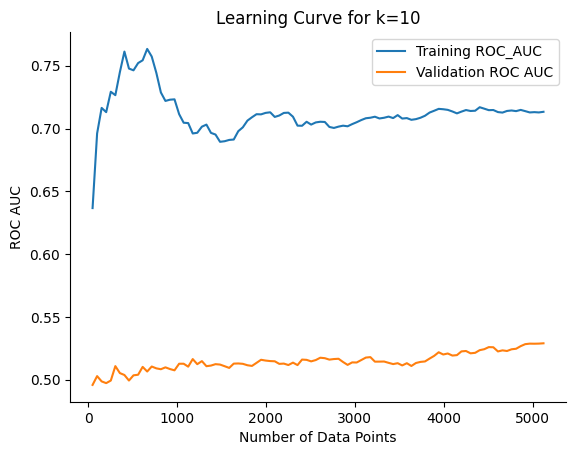

In [ ]:
# n_neighbors = 10

if not os.path.exists('k10.png'):
  train_sizes, train_scores, val_scores = learning_curve(
      KNeighborsClassifier(p=1, n_neighbors=10, n_jobs=-1),
      X_train_sfs, y_train,
      train_sizes=np.linspace(0.01, 1.0, 100),
      cv=5,
      scoring="roc_auc",
      n_jobs=-1
  )

  train_mean = train_scores.mean(axis=1)
  val_mean = val_scores.mean(axis=1)

  ax = sns.lineplot(x=train_sizes, y=train_mean, label="Training ROC_AUC")
  sns.lineplot(x=train_sizes, y=val_mean, label="Validation ROC AUC")
  ax.set_xlabel("Number of Data Points")
  ax.set_ylabel("ROC AUC")
  ax.set_title("Learning Curve for k=10");
  sns.despine()
else:
  img = Image(filename='k10.png')
  display(img)

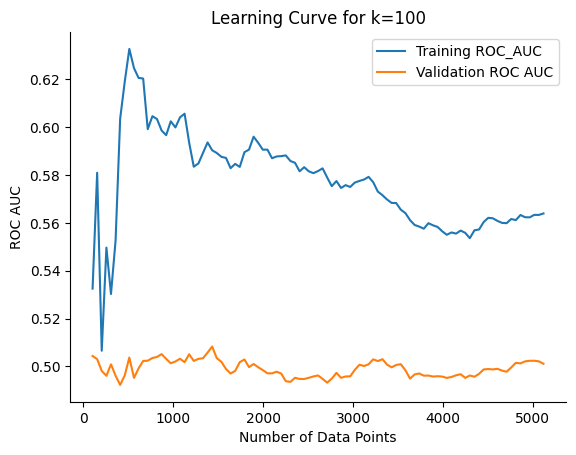

In [ ]:
# n_neighbors = 100

if not os.path.exists('k100.png'):
  train_sizes, train_scores, val_scores = learning_curve(
      KNeighborsClassifier(p=1, n_neighbors=100, n_jobs=-1),
      X_train_sfs, y_train,
      train_sizes=np.linspace(0.01, 1.0, 100),
      cv=5,
      scoring="roc_auc",
      n_jobs=-1
  )

  train_mean = train_scores.mean(axis=1)
  val_mean = val_scores.mean(axis=1)

  ax = sns.lineplot(x=train_sizes, y=train_mean, label="Training ROC_AUC")
  sns.lineplot(x=train_sizes, y=val_mean, label="Validation ROC AUC")
  ax.set_xlabel("Number of Data Points")
  ax.set_ylabel("ROC AUC")
  ax.set_title("Learning Curve for k=100");
  sns.despine()
else:
  display(Image(filename='k100.png'))

### Learning Curve Findings
As indicated by our `validation` set, our model has a steeper learning curve for when `k=10`

## Build of the final model
Our final model will incorporate all of the best parameters and model type as found above.

In [ ]:
model = KNeighborsClassifier(p=2, weights='distance',n_neighbors=10, n_jobs=-1)
model.fit(X_train_sfs, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=10, weights='distance')

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test_sfs))
auc = roc_auc_score(y_test, model.predict(X_test_sfs))
idx = np.argmax(tpr - fpr)
best_threshold = thresholds[idx]
display(f'Best Threshold: {best_threshold:.4f}')
display(f'False Positive Rate: {fpr[idx]:.4f}')
display(f'True Positive Rate: {tpr[idx]:.4f}')
display(f'ROC-AUC: {auc:.4f}')

'Best Threshold: 1.0000'

'False Positive Rate: 0.0708'

'True Positive Rate: 0.0825'

'ROC-AUC: 0.5058'

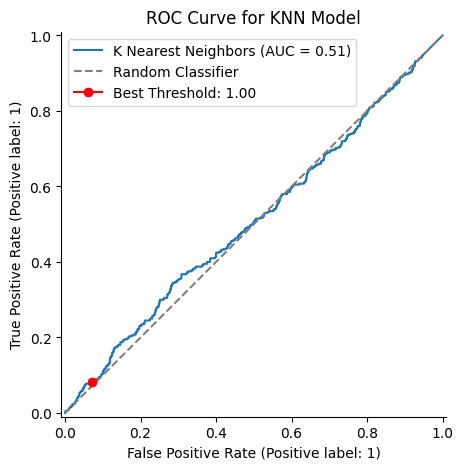

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

RocCurveDisplay.from_estimator(model,
                               X_test_sfs,
                               y_test,
                               name = f'K Nearest Neighbors',
                               ax=ax);

ax.plot(
    [0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier'
);
ax.plot(
    fpr[idx], tpr[idx], marker='o', color='red', label=f'Best Threshold: {best_threshold:.2f}'
)
# Optional: Add titles/labels and show the plot
ax.set_title("ROC Curve for KNN Model")
sns.despine()
ax.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test_sfs)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.93      0.83      1200
           1       0.28      0.08      0.13       400

    accuracy                           0.72      1600
   macro avg       0.52      0.51      0.48      1600
weighted avg       0.63      0.72      0.66      1600



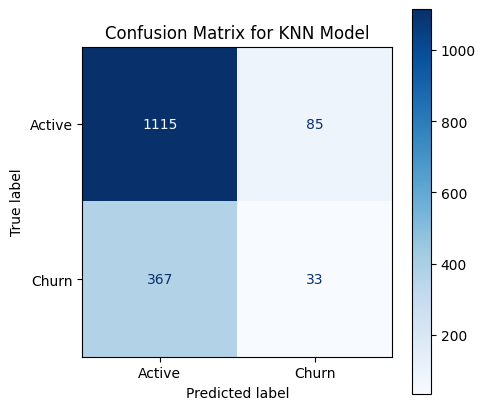

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(model, X_test_sfs, y_test, ax = ax,cmap='Blues');
ax.set_title("Confusion Matrix for KNN Model");
ax.set_xticklabels(['Active', 'Churn']);
ax.set_yticklabels(['Active', 'Churn']);

## Conclusions
- Our `KNeighbors` models performed the best
- Our feature elimination techniques proved to be extremely successful. Using the Forward Feature Selection subset of training data significanlt improved our ROC AUC score.
- Despite having a number of binary features, setting `p=2` in our model gave better performance than `p=1`.
- Our validation curve did not seem to significantly increase with the number of neighbors
- Our steepest learning curve was when the number of neighbors was equal to $10$. Had we had more data, we may have had a better model.
- Our best threshold had a false positive rate and true positive rate that were relatively small.
- Our untuned model did not significantly perform better than a majority classifier.